# Machine Learning Classification Models for Valence and Arousal

This notebook trains global machine learning models for binary classification of self-reported valence and arousal from video level sensor derived features. Each row represents one participant watching one empathy scene, with minimum and maximum features extracted from facial activation, EMG activation, expression intensity, breathing rate, HRV and motion related signals.

The numerical ratings are first converted into low, medium and high categories. For the binary classification task, only low and high samples are retained, while medium samples are excluded. This creates a clearer classification problem and allows the models to focus on distinguishing stronger differences in affective response.

Only sensor derived features are used as input features. Scene identity is not included, because the goal is to evaluate whether the sensor features themselves contain information relevant to valence and arousal prediction.

Models are evaluated using Leave One Participant Out cross validation. In each fold, all samples from one participant are held out as the test set, while the model is trained on the remaining participants. This prevents participant leakage and evaluates generalization to unseen participants.


In [36]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

In [37]:
CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = None
for candidate in [CURRENT_DIR, *CURRENT_DIR.parents]:
    if (candidate / "outputs").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find project root. Make sure the notebook is inside the project folder."
    )

OUTPUT_DIR = PROJECT_ROOT / "outputs"
DATA_PATH = OUTPUT_DIR / "video_level_valence_arousal_minmax.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset shape:", df.shape)

display(df.head())

Project root: /Users/victoriaprojkova/EmteqPRO-VR
Dataset path: /Users/victoriaprojkova/EmteqPRO-VR/outputs/video_level_valence_arousal_minmax.csv
Dataset shape: (384, 57)


,participant_id,participant_folder,recording_suffix,video_set,scene_name,scene_index,target_valence,target_arousal,target_discomfort,window_start,window_end,window_duration_seconds,segment_duration_seconds,trim_seconds_used,timing_source,feature_extraction_strategy,breathingrate_breathingrate_min,breathingrate_breathingrate_max,breathingrate_imu_motionintensity_min,breathingrate_imu_motionintensity_max,qc_breathingrate_ppg_quality_min,qc_breathingrate_ppg_quality_mean,emgactivation_emg_amplitude_zygo_weighted_min,emgactivation_emg_amplitude_zygo_weighted_max,emgactivation_emg_amplitude_orbi_weighted_min,emgactivation_emg_amplitude_orbi_weighted_max,emgactivation_emg_amplitude_front_weighted_min,emgactivation_emg_amplitude_front_weighted_max,emgactivation_emg_amplitude_corr_weighted_min,emgactivation_emg_amplitude_corr_weighted_max,expression_expression_intensity_min,expression_expression_intensity_max,expression_neutral_intensity_min,expression_neutral_intensity_max,facialactivation_facialactivation_min,facialactivation_facialactivation_max,hrv_hrv_mean_hr_min,hrv_hrv_mean_hr_max,hrv_hrv_rr_min,hrv_hrv_rr_max,hrv_hrv_sdnn_min,hrv_hrv_sdnn_max,hrv_hrv_sdsd_min,hrv_hrv_sdsd_max,hrv_hrv_rmssd_min,hrv_hrv_rmssd_max,hrv_imu_motionintensity_min,hrv_imu_motionintensity_max,qc_hrv_ppg_quality_min,qc_hrv_ppg_quality_mean,expression_smile_intensity_min,expression_smile_intensity_max,expression_eyebrow_raise_intensity_min,expression_eyebrow_raise_intensity_max,expression_frown_intensity_min,expression_frown_intensity_max,n_core_available_features
0,3,participant3,0,3,empathy_scene_1,1,1,3,1,1.704461e+09,1.704461e+09,120.0,200.0,40.0,details_start_end,split6_trimmed_fallback,10.446816,15.640528,0.0,0.846154,1.000000,1.000000,0.471619,74.557578,2.989772,193.801556,0.542198,28.991436,0.585319,16.507440,0.0,21.9,0.0,0.0,0.030521,0.425829,65.308989,73.409462,817.333333,918.709677,55.167892,139.210472,64.498062,177.132665,64.498062,177.180991,0.0,0.733333,1.0,1.0,5.5,21.9,0.0,0.0,7.4,8.3,28
1,3,participant3,0,3,empathy_scene_2,2,3,3,2,1.704461e+09,1.704461e+09,120.0,200.0,40.0,details_start_end,split6_trimmed_fallback,10.373120,15.919705,0.0,0.230769,1.000000,1.000000,0.758779,93.319921,2.326091,367.574970,-0.003053,59.168081,0.374244,12.118754,0.0,30.0,0.0,0.0,0.023948,0.722539,61.354020,75.227964,797.575758,977.931034,62.136443,122.216269,68.605959,132.837023,69.282032,132.842233,0.0,0.200000,1.0,1.0,4.4,30.0,13.1,21.3,0.0,0.0,28
2,3,participant3,0,3,empathy_scene_3,3,0,0,0,1.704461e+09,1.704461e+09,120.0,200.0,40.0,details_start_end,split6_trimmed_fallback,9.163744,15.569518,0.0,0.230769,1.000000,1.000000,4.026037,81.549640,12.058416,384.159678,-0.109454,63.268512,0.564494,23.403621,0.0,29.9,0.0,0.0,0.083460,0.664852,61.179898,72.727273,825.000000,980.714286,52.136573,119.990855,67.656543,157.585330,67.670602,158.065225,0.0,0.200000,1.0,1.0,4.5,29.9,0.0,0.0,0.0,0.0,28
3,3,participant3,0,3,empathy_scene_4,4,2,1,1,1.704461e+09,1.704461e+09,120.0,200.0,40.0,details_start_end,split6_trimmed_fallback,10.739601,14.466929,0.0,0.461538,0.978226,0.999453,2.112242,280.625786,7.264172,514.008341,-0.022390,24.817357,0.500666,14.036135,0.0,108.1,0.0,0.0,0.055702,1.687703,61.009818,69.915254,858.181818,983.448276,52.746775,123.979387,73.142475,158.307160,73.155479,158.401102,0.0,0.266667,1.0,1.0,5.0,108.1,0.0,0.0,0.0,0.0,28
4,4,participant4,0,1,empathy_scene_1,1,4,2,2,1.704737e+09,1.704737e+09,130.0,210.0,40.0,details_start_end,split6_trimmed_fallback,10.039688,14.118108,0.0,0.000000,1.000000,1.000000,2.737313,93.411802,0.376880,315.791773,0.190412,47.383158,0.851178,77.210891,0.0,0.0,0.0,0.0,0.027433,0.124473,89.743590,99.858357,600.851064,668.571429,23.385684,61.159173,28.791068,39.553271,28.919952,39.562828,0.0,0.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,28


In [38]:
print("Dataset shape:", df.shape)

print("\nNumber of participants:")
print(df["participant_id"].nunique())

print("\nRows by scene:")
display(df["scene_name"].value_counts().sort_index().to_frame("n_rows"))

print("\nRows by participant:")
rows_by_participant = (
    df.groupby(["participant_id", "participant_folder"])
    .size()
    .to_frame("n_rows")
    .reset_index()
)

display(rows_by_participant["n_rows"].describe())

print("\nMissing targets:")
target_cols = ["target_valence", "target_arousal"]

if "target_discomfort" in df.columns:
    target_cols.append("target_discomfort")

display(df[target_cols].isna().sum().to_frame("n_missing"))

Dataset shape: (384, 57)

Number of participants:
96

Rows by scene:


,n_rows
scene_name,
empathy_scene_1,96
empathy_scene_2,96
empathy_scene_3,96
empathy_scene_4,96



Rows by participant:


count    96.0
mean      4.0
std       0.0
min       4.0
25%       4.0
50%       4.0
75%       4.0
max       4.0
Name: n_rows, dtype: float64


Missing targets:


,n_missing
target_valence,0
target_arousal,0
target_discomfort,0


## Binary Target Definition

The original valence and arousal ratings are first grouped into three categories: low, medium and high. Ratings from 0 to 1 are treated as low, rating 2 is treated as medium, and ratings greater than or equal to 3 are treated as high.

For the binary classification experiments, only low and high samples are retained. Medium samples are excluded because they represent an intermediate response level and may be less clearly separable from the sensor features. 


In [39]:
def bin_low_medium_high(x):
    if pd.isna(x):
        return np.nan
    if x <= 1:
        return "low"
    if x == 2:
        return "medium"
    if x >= 3:
        return "high"
    return "unknown"


df["valence_category"] = df["target_valence"].apply(bin_low_medium_high)
df["arousal_category"] = df["target_arousal"].apply(bin_low_medium_high)

category_order = ["low", "medium", "high"]

print("Valence category counts:")
display(
    df["valence_category"]
    .value_counts()
    .reindex(category_order)
    .to_frame("count")
)

print("Arousal category counts:")
display(
    df["arousal_category"]
    .value_counts()
    .reindex(category_order)
    .to_frame("count")
)

Valence category counts:


,count
valence_category,
low,88
medium,82
high,214


Arousal category counts:


,count
arousal_category,
low,121
medium,131
high,132


In [40]:
metadata_cols = {
    "participant_id",
    "participant_folder",
    "recording_suffix",
    "video_set",
    "scene_name",
    "scene_index",
    "target_valence",
    "target_arousal",
    "target_discomfort",
    "window_start",
    "window_end",
    "window_duration_seconds",
    "segment_duration_seconds",
    "trim_seconds_used",
    "timing_source",
    "feature_extraction_strategy",
    "valence_category",
    "arousal_category",
    "discomfort_category",
    "n_core_available_features",
}

feature_cols = [
    col for col in df.columns
    if col not in metadata_cols
    and not col.startswith("qc_")
]

print("Number of original sensor feature columns:", len(feature_cols))
display(pd.DataFrame({"feature": feature_cols}))

Number of original sensor feature columns: 36


,feature
0,breathingrate_breathingrate_min
1,breathingrate_breathingrate_max
2,breathingrate_imu_motionintensity_min
3,breathingrate_imu_motionintensity_max
4,emgactivation_emg_amplitude_zygo_weighted_min
5,emgactivation_emg_amplitude_zygo_weighted_max
6,emgactivation_emg_amplitude_orbi_weighted_min
7,emgactivation_emg_amplitude_orbi_weighted_max
8,emgactivation_emg_amplitude_front_weighted_min
9,emgactivation_emg_amplitude_front_weighted_max


In [41]:
#feature engineering 
X_base = df[feature_cols].copy()
X_enhanced = X_base.copy()

for col in X_base.columns:
    if col.endswith("_min"):
        base = col.replace("_min", "")
        max_col = base + "_max"

        if max_col in X_base.columns:
            X_enhanced[f"{base}_mean"] = (
                X_base[col] + X_base[max_col]
            ) / 2

            X_enhanced[f"{base}_range"] = (
                X_base[max_col] - X_base[col]
            )

print("Original features:", X_base.shape[1])
print("Enhanced features:", X_enhanced.shape[1])
print("Added features:", X_enhanced.shape[1] - X_base.shape[1])

display(pd.DataFrame({"feature": X_enhanced.columns}))

Original features: 36
Enhanced features: 72
Added features: 36


,feature
0,breathingrate_breathingrate_min
1,breathingrate_breathingrate_max
2,breathingrate_imu_motionintensity_min
3,breathingrate_imu_motionintensity_max
4,emgactivation_emg_amplitude_zygo_weighted_min
5,emgactivation_emg_amplitude_zygo_weighted_max
6,emgactivation_emg_amplitude_orbi_weighted_min
7,emgactivation_emg_amplitude_orbi_weighted_max
8,emgactivation_emg_amplitude_front_weighted_min
9,emgactivation_emg_amplitude_front_weighted_max


In [42]:
#since the value counts from the medium low and high categories are imbalanced, binary classification will be tried

binary_label_mapping = {
    "low": 0,
    "high": 1,
}

inverse_binary_label_mapping = {
    0: "low",
    1: "high",
}

binary_label_order_numeric = [0, 1]
binary_label_order_names = ["low", "high"]


def prepare_binary_dataset(df, X, target_category_col):
    binary_mask = df[target_category_col].isin(["low", "high"])

    X_binary = X.loc[binary_mask].reset_index(drop=True)

    y_binary = (
        df.loc[binary_mask, target_category_col]
        .map(binary_label_mapping)
        .reset_index(drop=True)
    )

    groups_binary = (
        df.loc[binary_mask, "participant_id"]
        .reset_index(drop=True)
    )

    metadata_binary = (
        df.loc[
            binary_mask,
            [
                "participant_id",
                "participant_folder",
                "scene_name",
                "target_valence",
                "target_arousal",
                "valence_category",
                "arousal_category",
            ],
        ]
        .reset_index(drop=True)
    )

    return X_binary, y_binary, groups_binary, metadata_binary

In [43]:
X_valence_binary, y_valence_binary, groups_valence_binary, valence_binary_metadata = prepare_binary_dataset(
    df=df,
    X=X_enhanced,
    target_category_col="valence_category",
)

X_arousal_binary, y_arousal_binary, groups_arousal_binary, arousal_binary_metadata = prepare_binary_dataset(
    df=df,
    X=X_enhanced,
    target_category_col="arousal_category",
)

print("Valence binary dataset:")
print("X shape:", X_valence_binary.shape)
print("Participants:", groups_valence_binary.nunique())
display(
    y_valence_binary
    .value_counts()
    .sort_index()
    .rename(index=inverse_binary_label_mapping)
    .to_frame("count")
)

print("\nArousal binary dataset:")
print("X shape:", X_arousal_binary.shape)
print("Participants:", groups_arousal_binary.nunique())
display(
    y_arousal_binary
    .value_counts()
    .sort_index()
    .rename(index=inverse_binary_label_mapping)
    .to_frame("count")
)

Valence binary dataset:
X shape: (302, 72)
Participants: 96


,count
valence_category,
low,88
high,214



Arousal binary dataset:
X shape: (253, 72)
Participants: 95


,count
arousal_category,
low,121
high,132


In [44]:
logo = LeaveOneGroupOut()

n_valence_folds = logo.get_n_splits(
    X_valence_binary,
    y_valence_binary,
    groups_valence_binary,
)

n_arousal_folds = logo.get_n_splits(
    X_arousal_binary,
    y_arousal_binary,
    groups_arousal_binary,
)

print("Valence LOPO folds:", n_valence_folds)
print("Arousal LOPO folds:", n_arousal_folds)

Valence LOPO folds: 96
Arousal LOPO folds: 95


## Sampling Strategy for Binary Classification

The binary valence dataset is imbalanced, with substantially more high-valence than low valence samples. To address this, oversampling is tested as part of the model pipeline. Oversampling is applied only within the training data of each Leave One Participant Out fold, while the held out participant remains unchanged.

This avoids data leakage and allows the comparison between models trained with and without balancing. Random oversampling is used as a simple and robust baseline strategy, while SMOTE is also evaluated as a synthetic oversampling method.


In [48]:
%pip install imblearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.1/236.1 kB 5.4 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [49]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE

In [55]:
#this will allow us to try the models without oversampler, witn randomoversampling and smote

def make_preprocessor():
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("variance", VarianceThreshold()),
            ("scaler", StandardScaler()),
        ]
    )


def make_model_pipeline(classifier, sampler=None, use_feature_selection=False, k_best=30):
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
    ]

    if use_feature_selection:
        steps.append(
            ("feature_selection", SelectKBest(
                score_func=f_classif,
                k=k_best,
            ))
        )

    if sampler is not None:
        steps.append(("sampler", sampler))
        steps.append(("classifier", classifier))
        return ImbPipeline(steps=steps)

    steps.append(("classifier", classifier))
    return Pipeline(steps=steps)

In [58]:
def build_binary_classification_models(sampler=None, use_feature_selection=False, k_best=30):
    models = {
        "Dummy most frequent": make_model_pipeline(
            DummyClassifier(strategy="most_frequent"),
            sampler=None,
            use_feature_selection=False,
        ),

        "Logistic Regression": make_model_pipeline(
            LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=42,
            ),
            sampler=sampler,
            use_feature_selection=use_feature_selection,
            k_best=k_best,
        ),

        "Linear SVM": make_model_pipeline(
            SVC(
                kernel="linear",
                class_weight="balanced",
                random_state=42,
            ),
            sampler=sampler,
            use_feature_selection=use_feature_selection,
            k_best=k_best,
        ),

        "RBF SVM": make_model_pipeline(
            SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                class_weight="balanced",
                random_state=42,
            ),
            sampler=sampler,
            use_feature_selection=use_feature_selection,
            k_best=k_best,
        ),

        "KNN": make_model_pipeline(
            KNeighborsClassifier(
                n_neighbors=7,
                weights="distance",
            ),
            sampler=sampler,
            use_feature_selection=use_feature_selection,
            k_best=k_best,
        ),

        "Random Forest": make_model_pipeline(
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=1,
            ),
            sampler=sampler,
            use_feature_selection=use_feature_selection,
            k_best=k_best,
        ),

        "Extra Trees": make_model_pipeline(
            ExtraTreesClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=1,
            ),
            sampler=sampler,
            use_feature_selection=use_feature_selection,
            k_best=k_best,
        ),

        "Gradient Boosting": make_model_pipeline(
            GradientBoostingClassifier(
                n_estimators=150,
                learning_rate=0.05,
                max_depth=2,
                random_state=42,
            ),
            sampler=sampler,
            use_feature_selection=use_feature_selection,
            k_best=k_best,
        ),

        "Hist Gradient Boosting": make_model_pipeline(
            HistGradientBoostingClassifier(
                max_iter=150,
                learning_rate=0.05,
                max_leaf_nodes=15,
                random_state=42,
            ),
            sampler=sampler,
            use_feature_selection=use_feature_selection,
            k_best=k_best,
        ),

        "XGBoost": make_model_pipeline(
            XGBClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=2,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=1,
                verbosity=0,
            ),
            sampler=sampler,
            use_feature_selection=use_feature_selection,
            k_best=k_best,
        ),
    }

    return models

In [52]:
binary_model_experiments = {
    "no_sampling_all_features": {
        "sampler": None,
        "use_feature_selection": False,
        "description": "No oversampling, all enhanced features",
    },

    "random_oversampling_all_features": {
        "sampler": RandomOverSampler(random_state=42),
        "use_feature_selection": False,
        "description": "Random oversampling, all enhanced features",
    },

    "smote_all_features": {
        "sampler": SMOTE(random_state=42, k_neighbors=3),
        "use_feature_selection": False,
        "description": "SMOTE oversampling, all enhanced features",
    },

    "no_sampling_top30_features": {
        "sampler": None,
        "use_feature_selection": True,
        "description": "No oversampling, top 30 selected features",
    },

    "random_oversampling_top30_features": {
        "sampler": RandomOverSampler(random_state=42),
        "use_feature_selection": True,
        "description": "Random oversampling, top 30 selected features",
    },

    "smote_top30_features": {
        "sampler": SMOTE(random_state=42, k_neighbors=3),
        "use_feature_selection": True,
        "description": "SMOTE oversampling, top 30 selected features",
    },
}

for experiment_name, config in binary_model_experiments.items():
    print(experiment_name, "→", config["description"])

no_sampling_all_features → No oversampling, all enhanced features
random_oversampling_all_features → Random oversampling, all enhanced features
smote_all_features → SMOTE oversampling, all enhanced features
no_sampling_top30_features → No oversampling, top 30 selected features
random_oversampling_top30_features → Random oversampling, top 30 selected features
smote_top30_features → SMOTE oversampling, top 30 selected features


## LOPO Binary Classification Evaluation

The binary classification models are evaluated using Leave One Participant Out cross validation. In each fold, all available low/high samples from one participant are held out as the test set, while the model is trained on the remaining participants.

For the experiments with oversampling, the sampler is included inside the model pipeline. This means that oversampling is applied only to the training data within each LOPO fold, while the held-out participant remains unchanged. This avoids data leakage.

Because each participant contributes only a small number of samples, the performance is not interpreted fold by fold. Instead, predictions from all LOPO folds are pooled and the final metrics are computed across the full binary dataset.


In [59]:
# LOPO binary classification evaluation

def evaluate_lopo_binary_classification(
    X,
    y,
    groups,
    experiments,
    target_name,
    k_best=30,
):
    all_results = []
    all_predictions = {}

    for experiment_name, experiment_config in experiments.items():
        print("\n" + "=" * 80)
        print(f"Experiment: {experiment_name}")
        print(experiment_config["description"])
        print("=" * 80)

        models = build_binary_classification_models(
            sampler=experiment_config["sampler"],
            use_feature_selection=experiment_config["use_feature_selection"],
            k_best=k_best,
        )

        for model_name, model in models.items():
            print(f"Evaluating {model_name} for {target_name}...")

            y_pred = cross_val_predict(
                estimator=model,
                X=X,
                y=y,
                groups=groups,
                cv=logo,
                n_jobs=1,
            )

            all_predictions[(target_name, experiment_name, model_name)] = y_pred

            result = {
                "target": target_name,
                "experiment": experiment_name,
                "model": model_name,
                "accuracy": accuracy_score(y, y_pred),
                "balanced_accuracy": balanced_accuracy_score(y, y_pred),
                "macro_f1": f1_score(
                    y,
                    y_pred,
                    average="macro",
                    zero_division=0,
                ),
                "weighted_f1": f1_score(
                    y,
                    y_pred,
                    average="weighted",
                    zero_division=0,
                ),
                "precision_high": precision_score(
                    y,
                    y_pred,
                    pos_label=1,
                    zero_division=0,
                ),
                "recall_high": recall_score(
                    y,
                    y_pred,
                    pos_label=1,
                    zero_division=0,
                ),
                "recall_low": recall_score(
                    y,
                    y_pred,
                    pos_label=0,
                    zero_division=0,
                ),
                "n_samples": len(y),
                "n_groups": groups.nunique(),
            }

            all_results.append(result)

    results_df = (
        pd.DataFrame(all_results)
        .sort_values(
            by=["target", "macro_f1", "balanced_accuracy"],
            ascending=[True, False, False],
        )
        .reset_index(drop=True)
    )

    return results_df, all_predictions

## Valence Binary Classification

The first binary classification task focuses on distinguishing low and high valence samples. Medium-valence samples are excluded from this experiment. Since the valence binary dataset is imbalanced, the comparison includes models trained with no oversampling, random oversampling and SMOTE.


In [60]:
valence_binary_results, valence_binary_predictions = evaluate_lopo_binary_classification(
    X=X_valence_binary,
    y=y_valence_binary,
    groups=groups_valence_binary,
    experiments=binary_model_experiments,
    target_name="valence_binary",
    k_best=30,
)

display(valence_binary_results)


Experiment: no_sampling_all_features
No oversampling, all enhanced features
Evaluating Dummy most frequent for valence_binary...
Evaluating Logistic Regression for valence_binary...
Evaluating Linear SVM for valence_binary...
Evaluating RBF SVM for valence_binary...
Evaluating KNN for valence_binary...
Evaluating Random Forest for valence_binary...
Evaluating Extra Trees for valence_binary...
Evaluating Gradient Boosting for valence_binary...
Evaluating Hist Gradient Boosting for valence_binary...
Evaluating XGBoost for valence_binary...

Experiment: random_oversampling_all_features
Random oversampling, all enhanced features
Evaluating Dummy most frequent for valence_binary...
Evaluating Logistic Regression for valence_binary...
Evaluating Linear SVM for valence_binary...
Evaluating RBF SVM for valence_binary...
Evaluating KNN for valence_binary...
Evaluating Random Forest for valence_binary...
Evaluating Extra Trees for valence_binary...
Evaluating Gradient Boosting for valence_binar

,target,experiment,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_high,recall_high,recall_low,n_samples,n_groups
0,valence_binary,random_oversampling_top30_features,Linear SVM,0.698675,0.690367,0.667107,0.709877,0.839779,0.710280,0.670455,302,96
1,valence_binary,smote_top30_features,Random Forest,0.715232,0.668596,0.663923,0.718710,0.810680,0.780374,0.556818,302,96
2,valence_binary,no_sampling_top30_features,Extra Trees,0.725166,0.662224,0.663828,0.723739,0.801843,0.813084,0.511364,302,96
3,valence_binary,no_sampling_all_features,RBF SVM,0.705298,0.671623,0.661158,0.712182,0.817259,0.752336,0.590909,302,96
4,valence_binary,smote_all_features,Hist Gradient Boosting,0.711921,0.662914,0.658970,0.715035,0.806763,0.780374,0.545455,302,96
5,valence_binary,random_oversampling_top30_features,Gradient Boosting,0.701987,0.669286,0.658285,0.709270,0.816327,0.747664,0.590909,302,96
6,valence_binary,smote_top30_features,Linear SVM,0.695364,0.674650,0.657849,0.705118,0.824468,0.724299,0.625000,302,96
7,valence_binary,smote_top30_features,Extra Trees,0.715232,0.658560,0.657488,0.716163,0.801887,0.794393,0.522727,302,96
8,valence_binary,no_sampling_all_features,Extra Trees,0.731788,0.650170,0.657025,0.723835,0.790393,0.845794,0.454545,302,96
9,valence_binary,no_sampling_top30_features,Logistic Regression,0.688742,0.680013,0.656901,0.700509,0.833333,0.700935,0.659091,302,96


## Arousal Binary Classification

The same binary classification setup is applied to arousal. Ratings labelled as low and high are retained, while the middle class is excluded from the binary task. The same feature matrix, feature selection approach, models, and leave-one-participant-out validation strategy are used so that the arousal results can be compared directly with the valence classification results.

In [66]:
arousal_binary_mask = df["arousal_category"].isin(["low", "high"])

X_arousal_binary = X_enhanced.loc[arousal_binary_mask].copy()

y_arousal_binary = (
    df.loc[arousal_binary_mask, "arousal_category"]
    .map({"low": 0, "high": 1})
    .astype(int)
)

groups_arousal_binary = df.loc[arousal_binary_mask, "participant_id"].copy()

print("=" * 70)
print("AROUSAL BINARY CLASSIFICATION DATASET")
print("=" * 70)

print(f"X_arousal_binary shape: {X_arousal_binary.shape}")
print(f"y_arousal_binary shape: {y_arousal_binary.shape}")
print(f"Number of participants: {groups_arousal_binary.nunique()}")

print("\nClass distribution:")
print(f"  Low arousal:  {(y_arousal_binary == 0).sum()}")
print(f"  High arousal: {(y_arousal_binary == 1).sum()}")

AROUSAL BINARY CLASSIFICATION DATASET
X_arousal_binary shape: (253, 72)
y_arousal_binary shape: (253,)
Number of participants: 95

Class distribution:
  Low arousal:  121
  High arousal: 132


In [67]:
arousal_binary_results, arousal_binary_predictions = evaluate_lopo_binary_classification(
    X=X_arousal_binary,
    y=y_arousal_binary,
    groups=groups_arousal_binary,
    experiments=binary_model_experiments,
    target_name="arousal_binary",
    k_best=30
)

display(arousal_binary_results)


Experiment: no_sampling_all_features
No oversampling, all enhanced features
Evaluating Dummy most frequent for arousal_binary...
Evaluating Logistic Regression for arousal_binary...
Evaluating Linear SVM for arousal_binary...
Evaluating RBF SVM for arousal_binary...
Evaluating KNN for arousal_binary...
Evaluating Random Forest for arousal_binary...
Evaluating Extra Trees for arousal_binary...
Evaluating Gradient Boosting for arousal_binary...
Evaluating Hist Gradient Boosting for arousal_binary...
Evaluating XGBoost for arousal_binary...

Experiment: random_oversampling_all_features
Random oversampling, all enhanced features
Evaluating Dummy most frequent for arousal_binary...
Evaluating Logistic Regression for arousal_binary...
Evaluating Linear SVM for arousal_binary...
Evaluating RBF SVM for arousal_binary...
Evaluating KNN for arousal_binary...
Evaluating Random Forest for arousal_binary...
Evaluating Extra Trees for arousal_binary...
Evaluating Gradient Boosting for arousal_binar

,target,experiment,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_high,recall_high,recall_low,n_samples,n_groups
0,arousal_binary,no_sampling_all_features,Random Forest,0.565217,0.564394,0.564394,0.565217,0.583333,0.583333,0.545455,253,95
1,arousal_binary,no_sampling_all_features,KNN,0.561265,0.560950,0.560826,0.561429,0.581395,0.568182,0.553719,253,95
2,arousal_binary,smote_all_features,Random Forest,0.561265,0.560950,0.560826,0.561429,0.581395,0.568182,0.553719,253,95
3,arousal_binary,random_oversampling_all_features,Random Forest,0.561265,0.560606,0.560578,0.561333,0.580153,0.575758,0.545455,253,95
4,arousal_binary,random_oversampling_all_features,Extra Trees,0.561265,0.559573,0.559503,0.560714,0.576642,0.598485,0.520661,253,95
5,arousal_binary,random_oversampling_all_features,KNN,0.557312,0.557507,0.557139,0.557520,0.579365,0.553030,0.561983,253,95
6,arousal_binary,smote_all_features,KNN,0.553360,0.554063,0.553332,0.553485,0.577236,0.537879,0.570248,253,95
7,arousal_binary,random_oversampling_all_features,Hist Gradient Boosting,0.545455,0.545799,0.545341,0.545653,0.568000,0.537879,0.553719,253,95
8,arousal_binary,random_oversampling_top30_features,KNN,0.545455,0.545455,0.545199,0.545668,0.566929,0.545455,0.545455,253,95
9,arousal_binary,smote_all_features,Extra Trees,0.541502,0.541667,0.541323,0.541717,0.563492,0.537879,0.545455,253,95


In [68]:
from pathlib import Path

RESULTS_DIR = Path("ml_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

valence_binary_results.to_csv(
    RESULTS_DIR / "valence_binary_global_results.csv",
    index=False
)

arousal_binary_results.to_csv(
    RESULTS_DIR / "arousal_binary_global_results.csv",
    index=False
)

all_binary_results = pd.concat(
    [
        valence_binary_results,
        arousal_binary_results
    ],
    ignore_index=True
)

all_binary_results.to_csv(
    RESULTS_DIR / "all_binary_global_results.csv",
    index=False
)

print("Results saved in:", RESULTS_DIR.resolve())
display(all_binary_results)

Results saved in: /Users/victoriaprojkova/EmteqPRO-VR/ml_results


,target,experiment,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_high,recall_high,recall_low,n_samples,n_groups
0,valence_binary,random_oversampling_top30_features,Linear SVM,0.698675,0.690367,0.667107,0.709877,0.839779,0.710280,0.670455,302,96
1,valence_binary,smote_top30_features,Random Forest,0.715232,0.668596,0.663923,0.718710,0.810680,0.780374,0.556818,302,96
2,valence_binary,no_sampling_top30_features,Extra Trees,0.725166,0.662224,0.663828,0.723739,0.801843,0.813084,0.511364,302,96
3,valence_binary,no_sampling_all_features,RBF SVM,0.705298,0.671623,0.661158,0.712182,0.817259,0.752336,0.590909,302,96
4,valence_binary,smote_all_features,Hist Gradient Boosting,0.711921,0.662914,0.658970,0.715035,0.806763,0.780374,0.545455,302,96
5,valence_binary,random_oversampling_top30_features,Gradient Boosting,0.701987,0.669286,0.658285,0.709270,0.816327,0.747664,0.590909,302,96
6,valence_binary,smote_top30_features,Linear SVM,0.695364,0.674650,0.657849,0.705118,0.824468,0.724299,0.625000,302,96
7,valence_binary,smote_top30_features,Extra Trees,0.715232,0.658560,0.657488,0.716163,0.801887,0.794393,0.522727,302,96
8,valence_binary,no_sampling_all_features,Extra Trees,0.731788,0.650170,0.657025,0.723835,0.790393,0.845794,0.454545,302,96
9,valence_binary,no_sampling_top30_features,Logistic Regression,0.688742,0.680013,0.656901,0.700509,0.833333,0.700935,0.659091,302,96


In [69]:
print("=" * 70)
print("BEST VALENCE BINARY MODELS")
print("=" * 70)

display(
    valence_binary_results
    .sort_values(["balanced_accuracy", "macro_f1"], ascending=False)
    .head(10)
)

print("=" * 70)
print("BEST AROUSAL BINARY MODELS")
print("=" * 70)

display(
    arousal_binary_results
    .sort_values(["balanced_accuracy", "macro_f1"], ascending=False)
    .head(10)
)

BEST VALENCE BINARY MODELS


,target,experiment,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_high,recall_high,recall_low,n_samples,n_groups
0,valence_binary,random_oversampling_top30_features,Linear SVM,0.698675,0.690367,0.667107,0.709877,0.839779,0.710280,0.670455,302,96
10,valence_binary,random_oversampling_top30_features,Logistic Regression,0.685430,0.681022,0.655512,0.697869,0.836158,0.691589,0.670455,302,96
9,valence_binary,no_sampling_top30_features,Logistic Regression,0.688742,0.680013,0.656901,0.700509,0.833333,0.700935,0.659091,302,96
6,valence_binary,smote_top30_features,Linear SVM,0.695364,0.674650,0.657849,0.705118,0.824468,0.724299,0.625000,302,96
12,valence_binary,no_sampling_top30_features,Linear SVM,0.688742,0.673322,0.653754,0.699675,0.826087,0.710280,0.636364,302,96
18,valence_binary,smote_all_features,Linear SVM,0.678808,0.673003,0.648260,0.691508,0.830508,0.686916,0.659091,302,96
3,valence_binary,no_sampling_all_features,RBF SVM,0.705298,0.671623,0.661158,0.712182,0.817259,0.752336,0.590909,302,96
23,valence_binary,no_sampling_all_features,Linear SVM,0.675497,0.670667,0.645387,0.688499,0.829545,0.682243,0.659091,302,96
5,valence_binary,random_oversampling_top30_features,Gradient Boosting,0.701987,0.669286,0.658285,0.709270,0.816327,0.747664,0.590909,302,96
14,valence_binary,smote_top30_features,Logistic Regression,0.692053,0.668968,0.653272,0.701652,0.820106,0.724299,0.613636,302,96


BEST AROUSAL BINARY MODELS


,target,experiment,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_high,recall_high,recall_low,n_samples,n_groups
0,arousal_binary,no_sampling_all_features,Random Forest,0.565217,0.564394,0.564394,0.565217,0.583333,0.583333,0.545455,253,95
1,arousal_binary,no_sampling_all_features,KNN,0.561265,0.560950,0.560826,0.561429,0.581395,0.568182,0.553719,253,95
2,arousal_binary,smote_all_features,Random Forest,0.561265,0.560950,0.560826,0.561429,0.581395,0.568182,0.553719,253,95
3,arousal_binary,random_oversampling_all_features,Random Forest,0.561265,0.560606,0.560578,0.561333,0.580153,0.575758,0.545455,253,95
4,arousal_binary,random_oversampling_all_features,Extra Trees,0.561265,0.559573,0.559503,0.560714,0.576642,0.598485,0.520661,253,95
5,arousal_binary,random_oversampling_all_features,KNN,0.557312,0.557507,0.557139,0.557520,0.579365,0.553030,0.561983,253,95
6,arousal_binary,smote_all_features,KNN,0.553360,0.554063,0.553332,0.553485,0.577236,0.537879,0.570248,253,95
7,arousal_binary,random_oversampling_all_features,Hist Gradient Boosting,0.545455,0.545799,0.545341,0.545653,0.568000,0.537879,0.553719,253,95
8,arousal_binary,random_oversampling_top30_features,KNN,0.545455,0.545455,0.545199,0.545668,0.566929,0.545455,0.545455,253,95
9,arousal_binary,smote_all_features,Extra Trees,0.541502,0.541667,0.541323,0.541717,0.563492,0.537879,0.545455,253,95


## Global Model Results Visualization

The global binary classification results are visualized to compare model configurations for valence and arousal. The main comparison is based on balanced accuracy and macro F1-score, because these metrics are more informative than standard accuracy when class distributions are not perfectly balanced.

In [71]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)

FIGURES_DIR = Path("ml_global_figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

print("Figures will be saved in:", FIGURES_DIR.resolve())

Figures will be saved in: /Users/victoriaprojkova/EmteqPRO-VR/ml_global_figures


In [72]:
all_binary_results = pd.concat(
    [valence_binary_results, arousal_binary_results],
    ignore_index=True
)

all_binary_results = all_binary_results.sort_values(
    ["target", "balanced_accuracy", "macro_f1"],
    ascending=[True, False, False]
).reset_index(drop=True)

display(all_binary_results)

all_binary_results.to_csv(
    FIGURES_DIR / "all_binary_global_model_results.csv",
    index=False
)

,target,experiment,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_high,recall_high,recall_low,n_samples,n_groups
0,arousal_binary,no_sampling_all_features,Random Forest,0.565217,0.564394,0.564394,0.565217,0.583333,0.583333,0.545455,253,95
1,arousal_binary,no_sampling_all_features,KNN,0.561265,0.560950,0.560826,0.561429,0.581395,0.568182,0.553719,253,95
2,arousal_binary,smote_all_features,Random Forest,0.561265,0.560950,0.560826,0.561429,0.581395,0.568182,0.553719,253,95
3,arousal_binary,random_oversampling_all_features,Random Forest,0.561265,0.560606,0.560578,0.561333,0.580153,0.575758,0.545455,253,95
4,arousal_binary,random_oversampling_all_features,Extra Trees,0.561265,0.559573,0.559503,0.560714,0.576642,0.598485,0.520661,253,95
5,arousal_binary,random_oversampling_all_features,KNN,0.557312,0.557507,0.557139,0.557520,0.579365,0.553030,0.561983,253,95
6,arousal_binary,smote_all_features,KNN,0.553360,0.554063,0.553332,0.553485,0.577236,0.537879,0.570248,253,95
7,arousal_binary,random_oversampling_all_features,Hist Gradient Boosting,0.545455,0.545799,0.545341,0.545653,0.568000,0.537879,0.553719,253,95
8,arousal_binary,random_oversampling_top30_features,KNN,0.545455,0.545455,0.545199,0.545668,0.566929,0.545455,0.545455,253,95
9,arousal_binary,smote_all_features,Extra Trees,0.541502,0.541667,0.541323,0.541717,0.563492,0.537879,0.545455,253,95


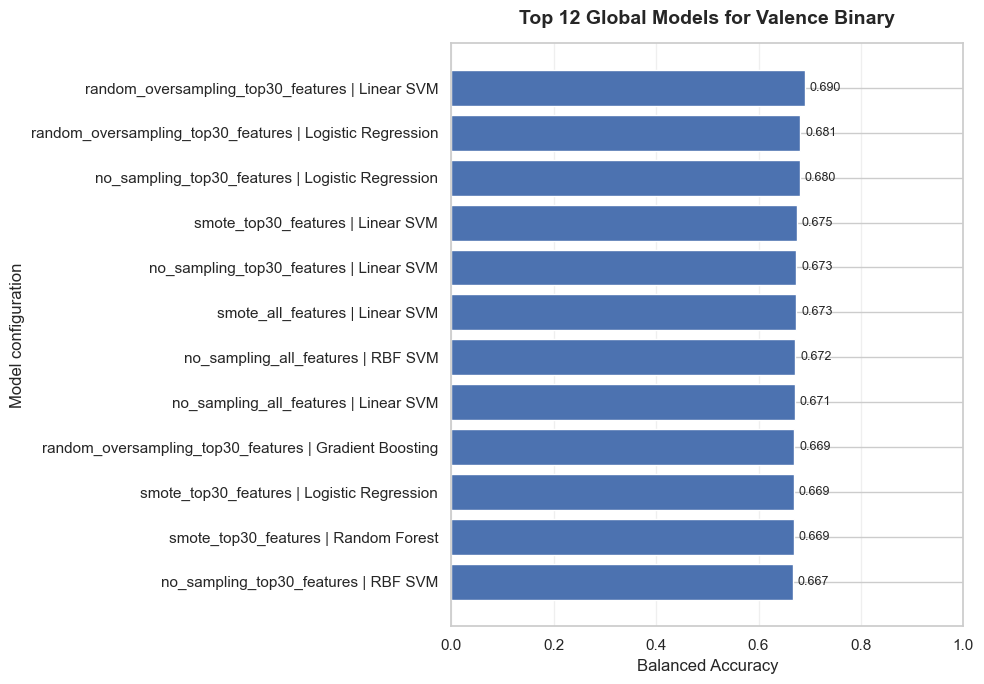

Saved: ml_global_figures/top_models_valence_binary_balanced_accuracy.png


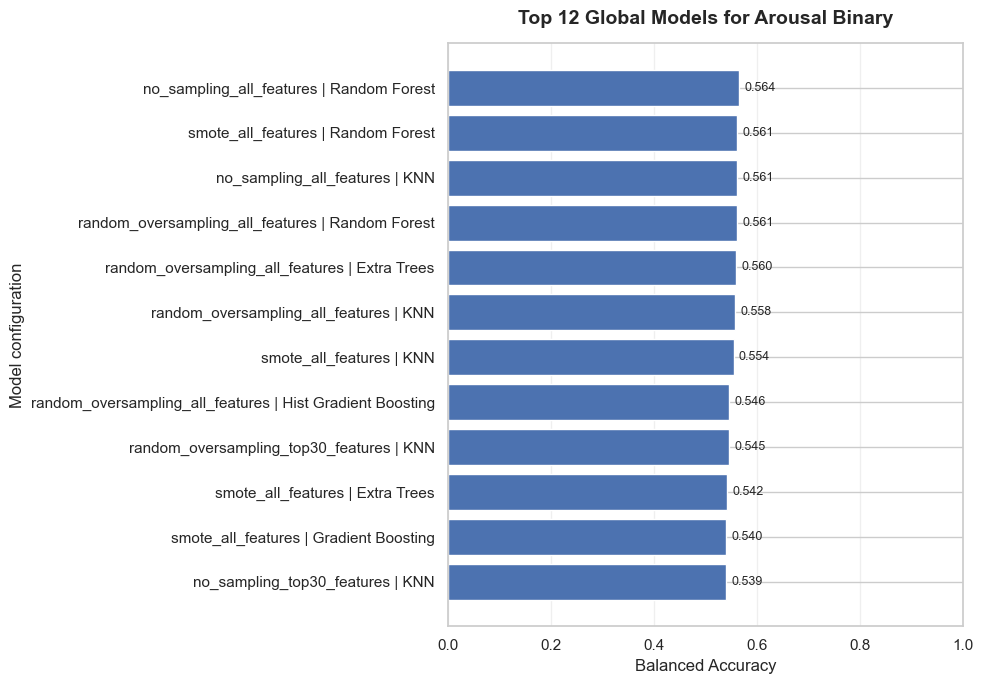

Saved: ml_global_figures/top_models_arousal_binary_balanced_accuracy.png


In [73]:
def plot_top_models(results_df, target_name, metric="balanced_accuracy", top_n=12):
    subset = (
        results_df[results_df["target"] == target_name]
        .sort_values([metric, "macro_f1"], ascending=False)
        .head(top_n)
        .copy()
    )
    
    subset["configuration"] = subset["experiment"] + " | " + subset["model"]
    subset = subset.sort_values(metric, ascending=True)
    
    plt.figure(figsize=(10, 7))
    
    bars = plt.barh(
        subset["configuration"],
        subset[metric]
    )
    
    plt.xlabel(metric.replace("_", " ").title())
    plt.ylabel("Model configuration")
    plt.title(
        f"Top {top_n} Global Models for {target_name.replace('_', ' ').title()}",
        fontsize=14,
        fontweight="bold",
        pad=14
    )
    plt.xlim(0, 1)
    plt.grid(axis="x", alpha=0.3)
    
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.3f}",
            va="center",
            fontsize=9
        )
    
    plt.tight_layout()
    
    filename = FIGURES_DIR / f"top_models_{target_name}_{metric}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved:", filename)


plot_top_models(
    all_binary_results,
    target_name="valence_binary",
    metric="balanced_accuracy",
    top_n=12
)

plot_top_models(
    all_binary_results,
    target_name="arousal_binary",
    metric="balanced_accuracy",
    top_n=12
)

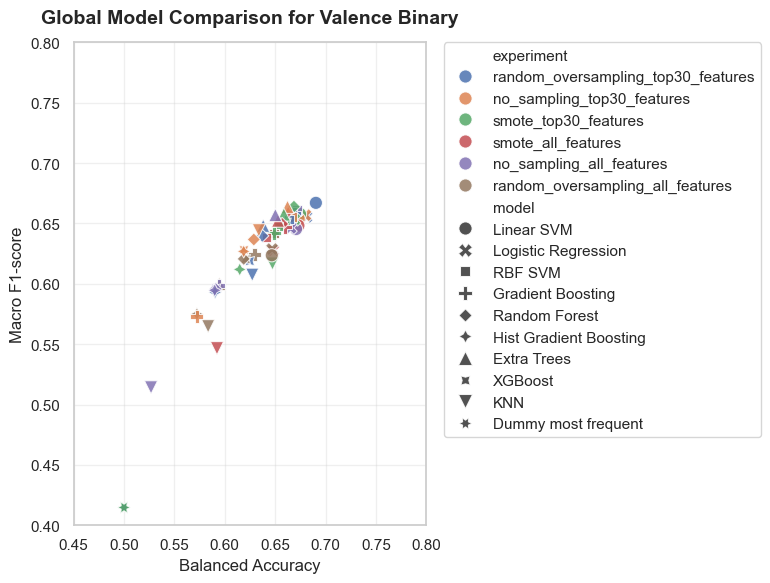

Saved: ml_global_figures/metric_scatter_valence_binary.png


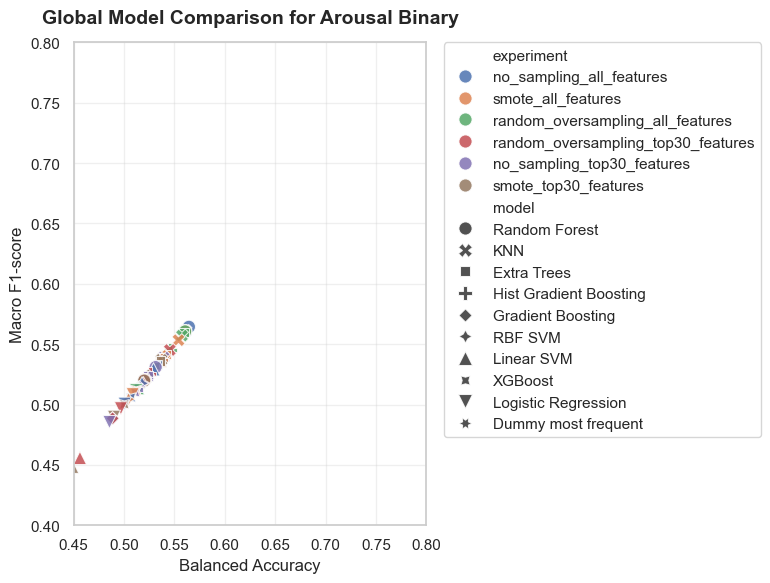

Saved: ml_global_figures/metric_scatter_arousal_binary.png


In [74]:
def plot_metric_scatter(results_df, target_name):
    subset = results_df[results_df["target"] == target_name].copy()
    
    plt.figure(figsize=(8, 6))
    
    sns.scatterplot(
        data=subset,
        x="balanced_accuracy",
        y="macro_f1",
        hue="experiment",
        style="model",
        s=90,
        alpha=0.85
    )
    
    plt.xlabel("Balanced Accuracy")
    plt.ylabel("Macro F1-score")
    plt.title(
        f"Global Model Comparison for {target_name.replace('_', ' ').title()}",
        fontsize=14,
        fontweight="bold",
        pad=14
    )
    plt.xlim(0.45, 0.80)
    plt.ylim(0.40, 0.80)
    plt.grid(alpha=0.3)
    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0
    )
    
    plt.tight_layout()
    
    filename = FIGURES_DIR / f"metric_scatter_{target_name}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved:", filename)


plot_metric_scatter(all_binary_results, "valence_binary")
plot_metric_scatter(all_binary_results, "arousal_binary")

In [77]:
def get_best_result_row(results_df):
    return (
        results_df
        .sort_values(["balanced_accuracy", "macro_f1"], ascending=False)
        .iloc[0]
    )

def get_prediction_for_result(predictions_dict, result_row):
    experiment = str(result_row["experiment"])
    model = str(result_row["model"])
    
    # 1. Try exact tuple key
    exact_tuple_key = (experiment, model)
    if exact_tuple_key in predictions_dict:
        return predictions_dict[exact_tuple_key]
    
    # 2. Try common string formats
    possible_string_keys = [
        f"{experiment} | {model}",
        f"{experiment}_{model}",
        f"{experiment}__{model}",
        f"{model}_{experiment}",
        f"{model} | {experiment}",
        model
    ]
    
    for key in possible_string_keys:
        if key in predictions_dict:
            return predictions_dict[key]
    
    # 3. Flexible matching for string keys
    for key in predictions_dict.keys():
        key_str = str(key)
        
        if experiment in key_str and model in key_str:
            return predictions_dict[key]
    
    # 4. Flexible matching for tuple keys
    for key in predictions_dict.keys():
        if isinstance(key, tuple):
            key_items = [str(item) for item in key]
            
            if experiment in key_items and model in key_items:
                return predictions_dict[key]
    
    print("=" * 70)
    print("COULD NOT MATCH PREDICTIONS")
    print("=" * 70)
    print("Looking for:")
    print("Experiment:", experiment)
    print("Model:", model)
    
    print("\nAvailable prediction keys:")
    for key in list(predictions_dict.keys())[:50]:
        print("  ", repr(key))
    
    raise KeyError(
        f"Could not find predictions for experiment='{experiment}', model='{model}'."
    )

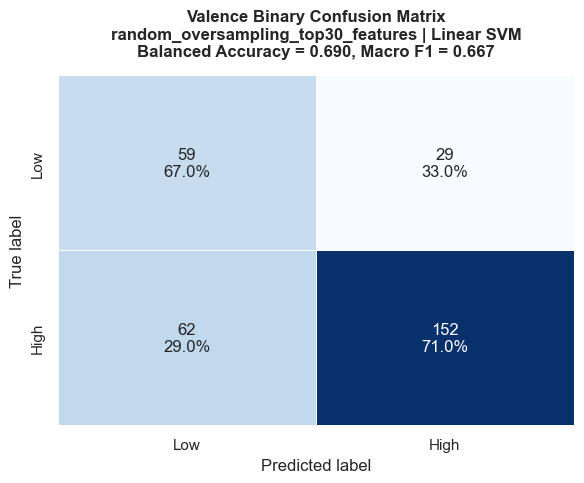

BEST MODEL FOR VALENCE_BINARY


,target,experiment,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_high,recall_high,recall_low,n_samples,n_groups
0,valence_binary,random_oversampling_top30_features,Linear SVM,0.698675,0.690367,0.667107,0.709877,0.839779,0.71028,0.670455,302,96



Classification report:
              precision    recall  f1-score   support

         Low       0.49      0.67      0.56        88
        High       0.84      0.71      0.77       214

    accuracy                           0.70       302
   macro avg       0.66      0.69      0.67       302
weighted avg       0.74      0.70      0.71       302

Saved: ml_global_figures/confusion_matrix_best_valence_binary.png


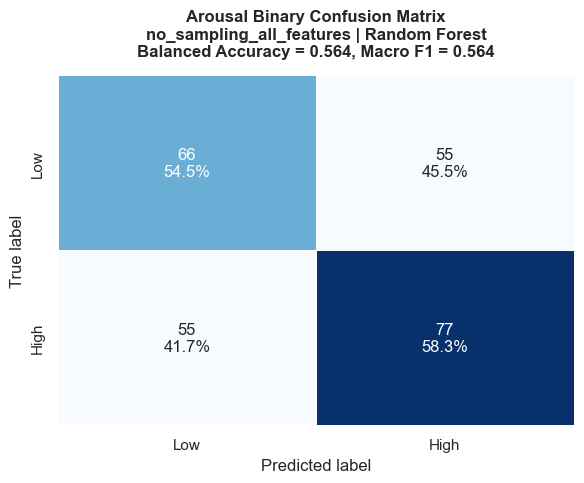

BEST MODEL FOR AROUSAL_BINARY


,target,experiment,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_high,recall_high,recall_low,n_samples,n_groups
0,arousal_binary,no_sampling_all_features,Random Forest,0.565217,0.564394,0.564394,0.565217,0.583333,0.583333,0.545455,253,95



Classification report:
              precision    recall  f1-score   support

         Low       0.55      0.55      0.55       121
        High       0.58      0.58      0.58       132

    accuracy                           0.57       253
   macro avg       0.56      0.56      0.56       253
weighted avg       0.57      0.57      0.57       253

Saved: ml_global_figures/confusion_matrix_best_arousal_binary.png


In [78]:
def plot_confusion_matrix_for_best_model(
    results_df,
    predictions_dict,
    y_true,
    target_name
):
    best_row = get_best_result_row(results_df)
    y_pred = get_prediction_for_result(predictions_dict, best_row)
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
    
    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n{cm_percent[i, j]:.1f}%"
    
    plt.figure(figsize=(6, 5))
    
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        cbar=False,
        xticklabels=["Low", "High"],
        yticklabels=["Low", "High"],
        linewidths=0.5,
        linecolor="white"
    )
    
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    
    title = (
        f"{target_name.replace('_', ' ').title()} Confusion Matrix\n"
        f"{best_row['experiment']} | {best_row['model']}\n"
        f"Balanced Accuracy = {best_row['balanced_accuracy']:.3f}, "
        f"Macro F1 = {best_row['macro_f1']:.3f}"
    )
    
    plt.title(title, fontsize=12, fontweight="bold", pad=14)
    plt.tight_layout()
    
    filename = FIGURES_DIR / f"confusion_matrix_best_{target_name}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("=" * 70)
    print(f"BEST MODEL FOR {target_name.upper()}")
    print("=" * 70)
    display(best_row.to_frame().T)
    
    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=["Low", "High"],
            zero_division=0
        )
    )
    
    print("Saved:", filename)
    
    return best_row, y_pred, cm


best_valence_row, best_valence_pred, cm_valence = plot_confusion_matrix_for_best_model(
    results_df=valence_binary_results,
    predictions_dict=valence_binary_predictions,
    y_true=y_valence_binary,
    target_name="valence_binary"
)

best_arousal_row, best_arousal_pred, cm_arousal = plot_confusion_matrix_for_best_model(
    results_df=arousal_binary_results,
    predictions_dict=arousal_binary_predictions,
    y_true=y_arousal_binary,
    target_name="arousal_binary"
)

In [79]:
best_global_models = pd.DataFrame([
    best_valence_row,
    best_arousal_row
]).reset_index(drop=True)

best_global_models = best_global_models[
    [
        "target",
        "experiment",
        "model",
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "weighted_f1",
        "precision_high",
        "recall_high",
        "recall_low",
        "n_samples",
        "n_groups"
    ]
]

display(best_global_models.round(4))

best_global_models.to_csv(
    FIGURES_DIR / "best_global_binary_models.csv",
    index=False
)

,target,experiment,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_high,recall_high,recall_low,n_samples,n_groups
0,valence_binary,random_oversampling_top30_features,Linear SVM,0.6987,0.6904,0.6671,0.7099,0.8398,0.7103,0.6705,302,96
1,arousal_binary,no_sampling_all_features,Random Forest,0.5652,0.5644,0.5644,0.5652,0.5833,0.5833,0.5455,253,95


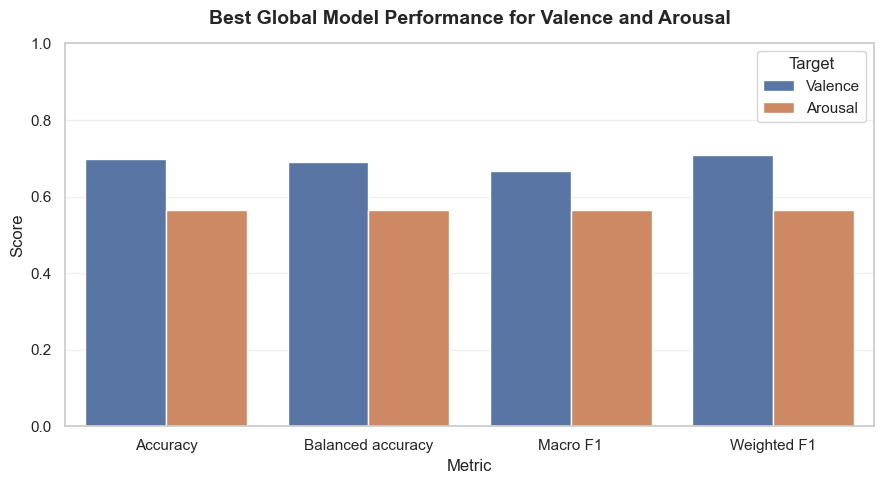

Saved: ml_global_figures/best_global_models_valence_vs_arousal.png


In [80]:
best_models_long = best_global_models.melt(
    id_vars=["target", "experiment", "model"],
    value_vars=["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"],
    var_name="metric",
    value_name="score"
)

best_models_long["target"] = best_models_long["target"].map({
    "valence_binary": "Valence",
    "arousal_binary": "Arousal"
})

best_models_long["metric"] = best_models_long["metric"].map({
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced accuracy",
    "macro_f1": "Macro F1",
    "weighted_f1": "Weighted F1"
})

plt.figure(figsize=(9, 5))

sns.barplot(
    data=best_models_long,
    x="metric",
    y="score",
    hue="target"
)

plt.xlabel("Metric")
plt.ylabel("Score")
plt.title(
    "Best Global Model Performance for Valence and Arousal",
    fontsize=14,
    fontweight="bold",
    pad=14
)
plt.ylim(0, 1)
plt.legend(title="Target")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

filename = FIGURES_DIR / "best_global_models_valence_vs_arousal.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", filename)

# Participant level performance

In [81]:
def participant_level_performance(y_true, y_pred, groups, target_name):
    eval_df = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_pred": np.asarray(y_pred),
        "participant_id": np.asarray(groups)
    })
    
    rows = []
    
    for participant_id, group_df in eval_df.groupby("participant_id"):
        y_t = group_df["y_true"]
        y_p = group_df["y_pred"]
        
        row = {
            "target": target_name,
            "participant_id": participant_id,
            "n_samples": len(group_df),
            "accuracy": accuracy_score(y_t, y_p),
            "n_low_true": int((y_t == 0).sum()),
            "n_high_true": int((y_t == 1).sum()),
            "n_low_pred": int((y_p == 0).sum()),
            "n_high_pred": int((y_p == 1).sum())
        }
        
        if y_t.nunique() == 2:
            row["balanced_accuracy"] = balanced_accuracy_score(y_t, y_p)
        else:
            row["balanced_accuracy"] = np.nan
        
        rows.append(row)
    
    return pd.DataFrame(rows)


valence_participant_perf = participant_level_performance(
    y_true=y_valence_binary,
    y_pred=best_valence_pred,
    groups=groups_valence_binary,
    target_name="Valence"
)

arousal_participant_perf = participant_level_performance(
    y_true=y_arousal_binary,
    y_pred=best_arousal_pred,
    groups=groups_arousal_binary,
    target_name="Arousal"
)

participant_perf_all = pd.concat(
    [valence_participant_perf, arousal_participant_perf],
    ignore_index=True
)

display(participant_perf_all)

participant_perf_all.to_csv(
    FIGURES_DIR / "participant_level_global_model_performance.csv",
    index=False
)

,target,participant_id,n_samples,accuracy,n_low_true,n_high_true,n_low_pred,n_high_pred,balanced_accuracy
0,Valence,3,3,0.666667,2,1,1,2,0.75
1,Valence,4,4,0.750000,1,3,0,4,0.50
2,Valence,5,3,1.000000,0,3,0,3,NaN
3,Valence,13,2,0.500000,1,1,0,2,0.50
4,Valence,14,2,1.000000,1,1,1,1,1.00
...,...,...,...,...,...,...,...,...,...
186,Arousal,101,3,0.000000,3,0,0,3,NaN
187,Arousal,102,4,0.500000,4,0,2,2,NaN
188,Arousal,103,2,0.500000,1,1,2,0,0.50
189,Arousal,104,2,0.500000,0,2,1,1,NaN


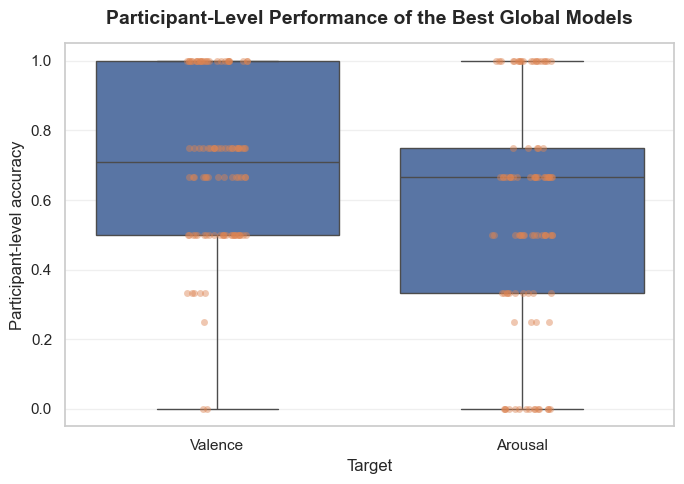

Saved: ml_global_figures/participant_level_accuracy_distribution.png


In [82]:
# variations per participant

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=participant_perf_all,
    x="target",
    y="accuracy"
)

sns.stripplot(
    data=participant_perf_all,
    x="target",
    y="accuracy",
    jitter=True,
    alpha=0.45
)

plt.xlabel("Target")
plt.ylabel("Participant-level accuracy")
plt.title(
    "Participant-Level Performance of the Best Global Models",
    fontsize=14,
    fontweight="bold",
    pad=14
)
plt.ylim(-0.05, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

filename = FIGURES_DIR / "participant_level_accuracy_distribution.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", filename)